In [1]:
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

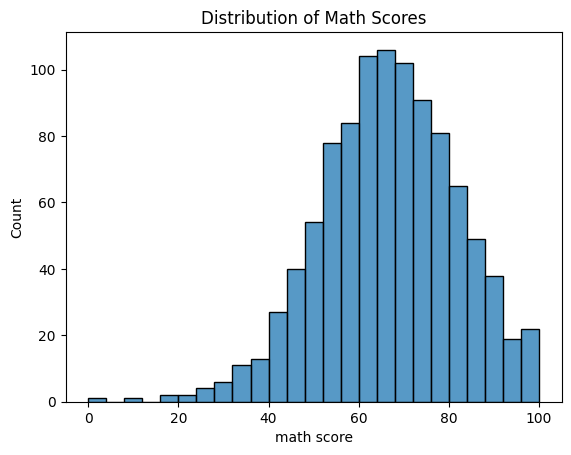

In [6]:
sns.histplot(df['math score'])
plt.title("Distribution of Math Scores")
plt.show()

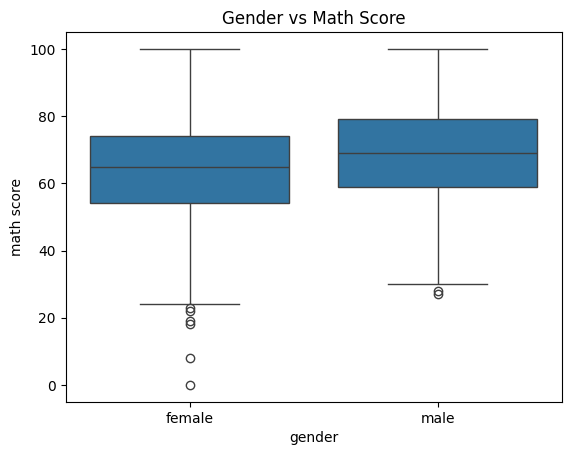

In [7]:
sns.boxplot(x='gender', y='math score', data=df)
plt.title("Gender vs Math Score")
plt.show()

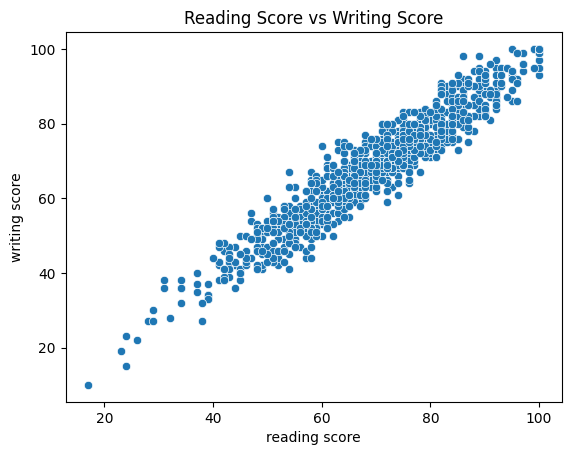

In [8]:
sns.scatterplot(x='reading score', y='writing score', data=df)
plt.title("Reading Score vs Writing Score")
plt.show()

In [9]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True


In [10]:
X = df.drop('math score', axis=1)
y = df['math score']

In [11]:
%pip install scikit-learn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [13]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [14]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [15]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error

In [17]:
print("Linear Regression Accuracy:", r2_score(y_test, pred_lr))
print("Decision Tree Accuracy:", r2_score(y_test, pred_dt))
print("Random Forest Accuracy:", r2_score(y_test, pred_rf))

Linear Regression Accuracy: 0.8804332983749564
Decision Tree Accuracy: 0.7257933807405654
Random Forest Accuracy: 0.8518797038261441


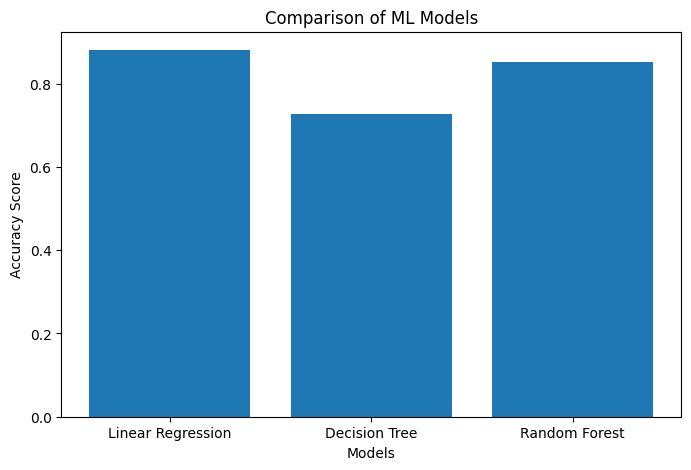

In [18]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']

scores = [
    r2_score(y_test, pred_lr),
    r2_score(y_test, pred_dt),
    r2_score(y_test, pred_rf)
]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.title("Comparison of ML Models")

plt.show()

In [19]:
sample = X_test.iloc[0:1]

prediction = rf.predict(sample)

print("Predicted Math Score:", prediction)
print("Actual Math Score:", y_test.iloc[0])

Predicted Math Score: [76.26]
Actual Math Score: 91


In [20]:
error = mean_absolute_error(y_test, pred_rf)

print("Mean Absolute Error:", error)

Mean Absolute Error: 4.658745833333334


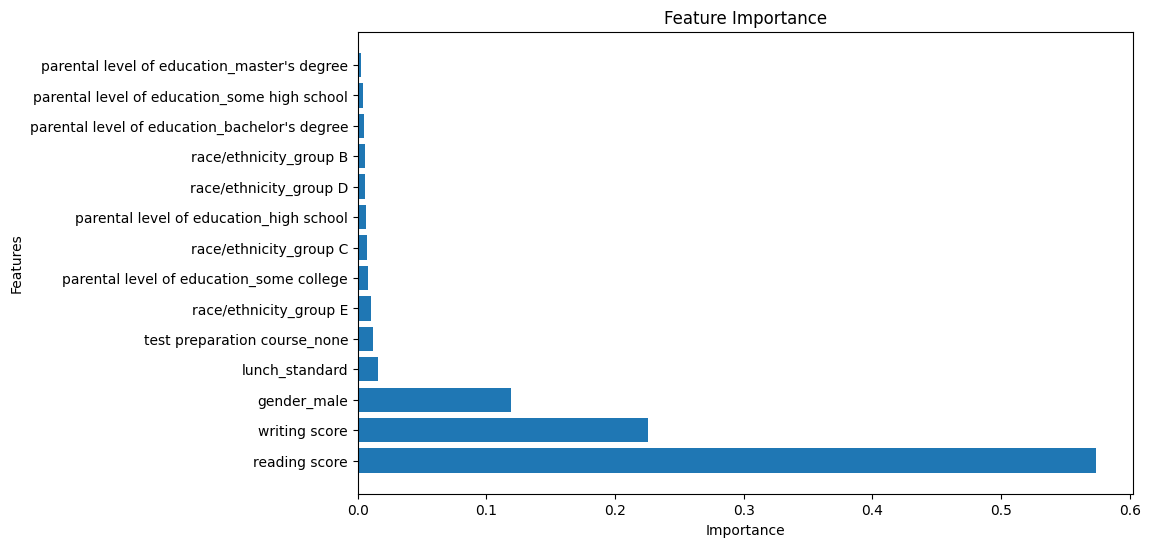

In [21]:
importance = rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

plt.barh(importance_df['Feature'], importance_df['Importance'])

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()

# Conclusion

This project predicts student performance using supervised machine learning algorithms.

We applied data preprocessing, visualization, and model training techniques to analyze student exam scores.

Three models were used:
- Linear Regression  
- Decision Tree Regressor  
- Random Forest Regressor  

Among these, Random Forest performed the best due to its ability to reduce overfitting and improve accuracy.

This project shows how machine learning can be used in education to understand and predict student outcomes.

In [22]:
import pandas as pd
from sklearn.metrics import r2_score

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_dt),
        r2_score(y_test, pred_rf)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.880433
1,Decision Tree,0.725793
2,Random Forest,0.851880


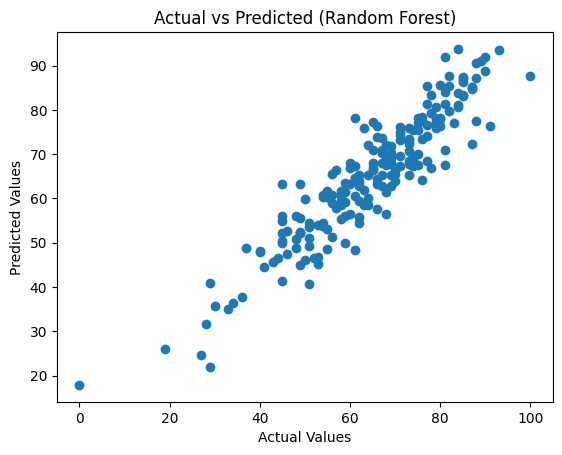

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [24]:
import pandas as pd

importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feat_imp.sort_values(by="Importance", ascending=False).head(10)

,Feature,Importance
0,reading score,0.573674
1,writing score,0.225855
2,gender_male,0.119140
12,lunch_standard,0.015478
13,test preparation course_none,0.011767
6,race/ethnicity_group E,0.010293
10,parental level of education_some college,0.007847
4,race/ethnicity_group C,0.007200
8,parental level of education_high school,0.006286
5,race/ethnicity_group D,0.005871
